<a href="https://colab.research.google.com/github/Joshua-David-Villafuerte/Visualizacion-por-Computadora-y-ML/blob/main/Practicas_Unidad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Convolucion 2D Manual
#Objetivo: Aplicar un filtro simple a una imagen
#Detector de bordes

import numpy as np
from scipy.signal import convolve2d

# Definimos una imagen pequeña de 4x4 píxeles como un arreglo de NumPy.
# Los valores representan intensidades (por ejemplo, niveles de gris).
imagen = np.array([
    [10, 10, 10, 10],
    [10, 50, 50, 10],
    [10, 50, 50, 10],
    [10, 10, 10, 10]
])

# Definimos un kernel (filtro) de 3x3.
# Este kernel es un detector de bordes (tipo Laplaciano),
# que resalta cambios bruscos de intensidad en la imagen.
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Aplicamos la convolución 2D entre la imagen y el kernel.
# mode='valid' indica que solo se calculan posiciones donde el kernel
# cabe completamente dentro de la imagen (sin padding).
# Esto reduce el tamaño de la salida.
resultado = convolve2d(imagen, kernel, mode='valid')

# Imprimimos el resultado de la convolución.
print(resultado)

[[200 200]
 [200 200]]


In [2]:
#Convolucion con Keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

# Creamos un modelo secuencial.
# Este tipo de modelo permite apilar capas una tras otra en orden.
model = Sequential([

    # Añadimos una capa convolucional 2D.
    Conv2D(
        filters=8,              # Número de filtros (kernels) que aprenderá la red.
        kernel_size=(3, 3),     # Tamaño del filtro: 3x3 píxeles.
        activation='relu',     # Función de activación ReLU (introduce no linealidad).
        input_shape=(28, 28, 1) # Forma de la entrada: imagen de 28x28 con 1 canal (escala de grises).
    )
])

# Mostramos un resumen del modelo.
# Incluye:
# - Tipo de capas
# - Forma de salida
# - Número de parámetros entrenables
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
#Convolucion 3D (Imagenes RGB)
#Objetivo

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D

# Creamos un modelo secuencial para imágenes RGB.
model_rgb = Sequential([

    # Capa convolucional 2D
    Conv2D(
        filters=16,              # Número de filtros (detectores de características)
        kernel_size=(3, 3),      # Tamaño del kernel: 3x3 píxeles
        activation='relu',      # Función de activación ReLU
        input_shape=(32, 32, 3) # Entrada: imagen de 32x32 con 3 canales (RGB)
    )
])

# Mostramos el resumen del modelo
model_rgb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 448 (1.75 KB)

 Trainable params: 448 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

***EJERCICIO 2***

In [5]:
import tensorflow as tf

# Cargamos el dataset MNIST (dígitos escritos a mano)
# x_train: imágenes de entrenamiento
# y_train: etiquetas correspondientes
# x_test: imágenes de prueba
# y_test: etiquetas de prueba
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Mostramos la forma original de los datos
# (60000, 28, 28) → 60000 imágenes de 28x28 píxeles (sin canal explícito)
print(x_train.shape)

# Normalizamos los valores de los píxeles
# Originalmente están en rango [0, 255]
# Ahora estarán en rango [0, 1]
x_train = x_train / 255
x_test = x_test / 255

# Reajustamos la forma de los datos para incluir el canal
# -1 permite que NumPy calcule automáticamente el número de muestras
# Resultado: (num_imágenes, 28, 28, 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Mostramos la nueva forma
# Ahora incluye el canal (escala de grises)
print(x_train.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000, 28, 28, 1)


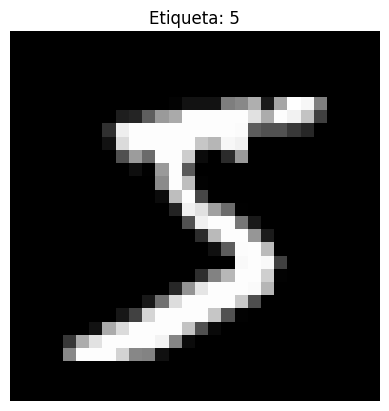

In [6]:
import matplotlib.pyplot as plt

# Mostramos la primera imagen del conjunto de entrenamiento
# x_train[0] es una imagen de 28x28 píxeles (con canal si ya hiciste reshape)
plt.imshow(x_train[0], cmap='gray')

# Añadimos el título con su etiqueta real (el número que representa la imagen)
plt.title(f"Etiqueta: {y_train[0]}")

# Ocultamos los ejes para una visualización más limpia
plt.axis("off")

# Mostramos la imagen en pantalla
plt.show()

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Creamos un modelo secuencial (capas apiladas en orden)
model = Sequential([

    # Primera capa convolucional
    Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)  # Imagen en escala de grises (MNIST)
    ),

    # Capa de pooling (reduce dimensiones espaciales)
    MaxPooling2D(pool_size=(2, 2)),

    # Segunda capa convolucional
    Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    # Segunda capa de pooling
    MaxPooling2D(pool_size=(2, 2)),

    # Aplanamos los datos 2D a 1D para conectarlos a capas densas
    Flatten(),

    # Capa totalmente conectada (aprende combinaciones complejas)
    Dense(
        128,
        activation='relu'
    ),

    # Dropout: apaga aleatoriamente el 50% de neuronas durante entrenamiento
    # para evitar overfitting (sobreajuste)
    Dropout(0.5),

    # Capa de salida
    Dense(
        10,              # 10 clases (dígitos del 0 al 9)
        activation='softmax'  # Convierte salidas en probabilidades
    )
])

# Mostramos la arquitectura del modelo
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compilamos el modelo: definimos cómo aprenderá

model.compile(
    optimizer='adam',  # Algoritmo de optimización
                        # Ajusta los pesos automáticamente usando gradiente descendente adaptativo

    loss='sparse_categorical_crossentropy',
    # Función de pérdida para clasificación multiclase
    # Se usa cuando las etiquetas (y_train) son enteros (0–9) y no one-hot

    metrics=['accuracy']  # Métrica para evaluar el rendimiento (porcentaje de aciertos)
)

In [9]:
# Evaluamos el modelo usando el conjunto de prueba (datos que NO vio durante entrenamiento)
test_loss, test_acc = model.evaluate(x_test, y_test)

# Mostramos la precisión (accuracy) del modelo en los datos de prueba
print(f"Precisión en el conjunto de prueba:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1008 - loss: 2.3061
Precisión en el conjunto de prueba: 0.10080000013113022


In [10]:
import numpy as np

# Generamos predicciones para todo el conjunto de prueba
# El resultado es un arreglo donde cada fila contiene probabilidades para cada clase (0–9)
pred = model.predict(x_test)

# np.argmax obtiene el índice con la mayor probabilidad
# Es decir, la clase que el modelo considera más probable
print("Prediccion:", np.argmax(pred[0]))

# Mostramos la etiqueta real para comparar
print("Etiqueta real", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Prediccion: 0
Etiqueta real 7


In [11]:
import matplotlib.pyplot as plt

# ===== Gráfica de la función de pérdida (Loss) =====
plt.figure()

# Pérdida en entrenamiento
plt.plot(history.history['loss'], label='Training Loss')

# Pérdida en validación
plt.plot(history.history['val_loss'], label='Validation Loss')

# Etiqueta del eje Y
plt.ylabel('Loss')

# Leyenda para identificar cada línea
plt.legend()

# Cuadrícula para mejor lectura
plt.grid()

# Mostramos la gráfica
plt.show()


# ===== Gráfica de la precisión (Accuracy) =====
plt.figure()

# Precisión en entrenamiento
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Precisión en validación
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Etiqueta del eje Y
plt.ylabel('Accuracy')

# Leyenda
plt.legend()

# Cuadrícula
plt.grid()

# Mostramos la gráfica
plt.show()

model.save("cnn_mnist.keras")

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

***EJERCICIO 3***

In [ ]:
# =====================================================
# PRÁCTICA - CREACIÓN DE MODELOS CNN
# Ejercicio 1: Diseñar una CNN propia
# =====================================================

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# -----------------------------------------------------
# Cargar dataset CIFAR-10
# -----------------------------------------------------
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalización
x_train = x_train / 255.0
x_test = x_test / 255.0


# =====================================================
# EJERCICIO 1
# Diseñar una CNN propia
# =====================================================

cnn_model = models.Sequential([

    # Extrae características básicas
    layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    layers.MaxPooling2D((2,2)),

    # Detecta patrones más complejos
    layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    # Convertir a vector
    layers.Flatten(),

    # Capa densa para aprendizaje
    layers.Dense(
        128,
        activation='relu'
    ),

    # Salida 10 clases
    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

history_base = cnn_model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

In [ ]:
# =====================================================
# EJERCICIO 2
# Mejorar modelo con regularización y Data Augmentation
# =====================================================

from tensorflow.keras.layers import Dropout

# Generador de imágenes aumentadas
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(x_train)

# Modelo mejorado
cnn_mejorada = models.Sequential([

    layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),   # Regularización

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_mejorada.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mejorada = cnn_mejorada.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test)
)

In [ ]:
# =====================================================
# EJERCICIO 3
# Comparar CNN propia vs modelo preentrenado VGG16
# =====================================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Redimensionar imágenes para VGG16
x_train_vgg = tf.image.resize(x_train, (224,224))
x_test_vgg = tf.image.resize(x_test, (224,224))

# Modelo base preentrenado
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Modelo final
vgg_model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    x_train_vgg,
    y_train,
    epochs=5,
    validation_data=(x_test_vgg, y_test)
)

In [ ]:
# =====================================================
# GRÁFICA COMPARATIVA FINAL
# =====================================================

plt.plot(
    history_base.history['val_accuracy'],
    label='CNN Propia'
)

plt.plot(
    history_mejorada.history['val_accuracy'],
    label='CNN Mejorada'
)

plt.plot(
    history_vgg.history['val_accuracy'],
    label='VGG16'
)

plt.title("Comparación de Modelos CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

***EJERCICIO 4***

***Arquitecturas CNN Ejercicio 1: Comparar CNN simple vs VGG16 preentrenada***

Una CNN simple se entrena desde cero y tiene menos capas, por lo que es más rápida pero suele obtener menor precisión. VGG16 preentrenada usa aprendizaje previo (Transfer Learning), por lo que aprende más rápido y normalmente logra mejor accuracy.

***Conclusión:*** VGG16 dio mejores resultados, aunque consume más recursos.

***Ejercicio 2: Número de parámetros vs accuracy***

Mientras más parámetros tiene una red, mayor capacidad de aprendizaje posee. Sin embargo, también requiere más tiempo de entrenamiento y puede sobreajustarse.

***Conclusión:*** Más parámetros no siempre significan mejor accuracy.

***Ejercicio 3: ¿Siempre una red más profunda es mejor?***

No siempre. Una red profunda puede aprender patrones complejos, pero necesita más datos, tiempo y potencia de cómputo.

***Conclusión:*** La mejor red depende del problema y del conjunto de datos.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

# =========================
# 1. CNN SIMPLE (desde cero)
# =========================
cnn_simple = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_simple.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# =========================
# 2. VGG16 PREENTRENADA
# =========================
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

# Congelamos capas (Transfer Learning)
base_model.trainable = False

vgg16_model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

vgg16_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenamiento del modelo CNN simple
history_simple = cnn_simple.fit(
    x_train, y_train,          # Datos de entrenamiento (entradas y etiquetas)
    epochs=5,                 # Número de veces que recorrerá todo el conjunto de datos
    validation_data=(x_test, y_test)  # Datos usados para validar el rendimiento en cada época
)

# Entrenamiento del modelo basado en VGG16
history_vgg = vgg16_model.fit(
    x_train, y_train,         # Datos de entrenamiento
    epochs=5,                # Cantidad de épocas de entrenamiento
    validation_data=(x_test, y_test)  # Datos de prueba para validar precisión y pérdida
)

In [ ]:
import matplotlib.pyplot as plt  # Librería para crear gráficas

# Graficar la precisión de validación del modelo CNN simple
plt.plot(
    history_simple.history['val_accuracy'],
    label='CNN simple'
)

# Graficar la precisión de validación del modelo VGG16
plt.plot(
    history_vgg.history['val_accuracy'],
    label='VGG16'
)

# Título principal de la gráfica
plt.title("Comparación CNN vs VGG16")

# Etiqueta del eje X (épocas de entrenamiento)
plt.xlabel("Epoch")

# Etiqueta del eje Y (precisión en validación)
plt.ylabel("Validation Accuracy")

# Mostrar nombres de cada línea
plt.legend()

# Activar cuadrícula para mejor lectura
plt.grid()

# Mostrar gráfica en pantalla
plt.show()

In [ ]:
# -------------------------------
# Modelo profundo (Deep Model)
# -------------------------------
deep_model = models.Sequential([

    # Primera capa convolucional con 32 filtros de 3x3
    layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(32,32,3)   # Imagen de entrada de 32x32 píxeles con 3 canales RGB
    ),

    # Segunda capa convolucional con 32 filtros
    layers.Conv2D(
        32, (3,3),
        activation='relu'
    ),

    # Reducción de dimensiones con MaxPooling
    layers.MaxPooling2D((2,2)),

    # Tercera capa convolucional con 64 filtros
    layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),

    # Cuarta capa convolucional con 64 filtros
    layers.Conv2D(
        64, (3,3),
        activation='relu'
    ),

    # Segunda reducción de dimensiones
    layers.MaxPooling2D((2,2)),

    # Convertir matriz 2D en vector 1D
    layers.Flatten(),

    # Capa totalmente conectada con 128 neuronas
    layers.Dense(
        128,
        activation='relu'
    ),

    # Capa de salida con 10 clases
    layers.Dense(
        10,
        activation='softmax'
    )
])

# -------------------------------
# Modelo superficial (Shallow Model)
# -------------------------------
shallow_model = models.Sequential([

    # Una sola capa convolucional
    layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    # Reducción de dimensiones
    layers.MaxPooling2D((2,2)),

    # Aplanar datos
    layers.Flatten(),

    # Capa oculta con 64 neuronas
    layers.Dense(
        64,
        activation='relu'
    ),

    # Capa de salida con 10 clases
    layers.Dense(
        10,
        activation='softmax'
    )
])

# -------------------------------
# Compilación del modelo profundo
# -------------------------------
deep_model.compile(
    optimizer='adam',                         # Algoritmo de optimización
    loss='sparse_categorical_crossentropy',  # Función de pérdida para clasificación multiclase
    metrics=['accuracy']                     # Métrica de evaluación
)

# -------------------------------
# Compilación del modelo superficial
# -------------------------------
shallow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

***EJERCICIO 5***

***Práctica - Data Augmentation Ejercicio 1: CNN con y sin Data Augmentation***

Se entrenó una CNN normal y otra aplicando rotaciones, zoom y volteos en imágenes.

*Resultado: El modelo con Data Augmentation generalizó mejor.*

***Ejercicio 2: Visualización de imágenes aumentadas***

Las imágenes generadas mostraron cambios como giros, acercamientos y desplazamientos, conservando la clase original.

***Ejercicio 3: Impacto en accuracy de validación***

El uso de Data Augmentation mejoró la precisión en validación y redujo el sobreajuste.

***Conclusión:*** Es una técnica útil cuando se tienen pocos datos.

In [ ]:
# ===============================================
# PRÁCTICA - DATA AUGMENTATION
# Ejercicio 1: CNN con y sin Data Augmentation
# ===============================================

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalizar imágenes
x_train = x_train / 255.0
x_test = x_test / 255.0

# -----------------------------------------------
# Modelo CNN base
# -----------------------------------------------
def crear_modelo():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ===============================================
# Entrenamiento SIN Data Augmentation
# ===============================================
modelo_normal = crear_modelo()

history_normal = modelo_normal.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


# ===============================================
# Entrenamiento CON Data Augmentation
# ===============================================
datagen = ImageDataGenerator(
    rotation_range=20,      # Rotación
    zoom_range=0.2,         # Zoom
    horizontal_flip=True,   # Volteo horizontal
    width_shift_range=0.1,  # Desplazamiento horizontal
    height_shift_range=0.1  # Desplazamiento vertical
)

datagen.fit(x_train)

modelo_aug = crear_modelo()

history_aug = modelo_aug.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=5,
    validation_data=(x_test, y_test)
)

In [ ]:
# ===============================================
# Ejercicio 2: Visualización de imágenes aumentadas
# ===============================================

# Tomar una imagen del dataset
img = x_train[0].reshape((1,32,32,3))

# Generar imágenes aumentadas
plt.figure(figsize=(10,6))

i = 0
for batch in datagen.flow(img, batch_size=1):

    plt.subplot(2,3,i+1)
    plt.imshow(batch[0])
    plt.axis("off")

    i += 1
    if i == 6:
        break

plt.suptitle("Ejemplos de Data Augmentation")
plt.show()

In [ ]:
# ===============================================
# Ejercicio 3: Comparación Accuracy Validación
# ===============================================

plt.plot(
    history_normal.history['val_accuracy'],
    label='Sin Augmentation'
)

plt.plot(
    history_aug.history['val_accuracy'],
    label='Con Augmentation'
)

plt.title("Impacto del Data Augmentation")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

EJERCICIO 6

In [ ]:
# Importar librerías necesarias
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import cifar10

# ---------------------------------------------------
# Cargar dataset CIFAR-10
# ---------------------------------------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Redimensionar imágenes de 32x32 a 224x224
x_train = tf.image.resize(x_train, (224, 224)) / 255.0
x_test = tf.image.resize(x_test, (224, 224)) / 255.0

# ---------------------------------------------------
# Cargar modelo base VGG16 preentrenado
# ---------------------------------------------------
base_model = VGG16(
    weights='imagenet',         # Pesos entrenados en ImageNet
    include_top=False,         # Sin la parte final original
    input_shape=(224, 224, 3) # Tamaño de entrada requerido
)

# Congelar capas convolucionales
base_model.trainable = False

# ---------------------------------------------------
# Crear nuevo modelo
# ---------------------------------------------------
model = Sequential([
    base_model,                 # Base preentrenada
    Flatten(),                 # Convertir salida a vector
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 clases CIFAR-10
])

# ---------------------------------------------------
# Compilar modelo
# ---------------------------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar estructura del modelo
model.summary()

# ---------------------------------------------------
# Entrenamiento
# ---------------------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

# ---------------------------------------------------
# Evaluación final
# ---------------------------------------------------
loss, acc = model.evaluate(x_test, y_test)

print("Precisión final:", acc)